**Ejemplos en Python**
==
Magister Jorge Córdoba
===
**@CEFCAPACITAR**

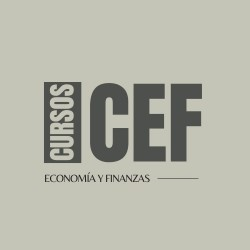

<div style="background:#1F3864; padding:30px; border-radius:10px; text-align:center;">
  <h1 style="color:white; margin:0; font-size:2.2em;">📊 Ejemplos</h1>
  <h2 style="color:#AED6F1; margin:10px 0 0 0; font-size:1.3em;">Finanzas Corporativas — Primera parte</h2>
  

## 📋 Índice de Casos

| # | Caso | Tema del Módulo 1 | Nivel |
|---|------|-------------------|-------|
| 01 | Valor tiempo del dinero: VP y VF | Introducción y Valor | Inicial |
| 02 | Valuación de bonos del gobierno | Valuación de Bonos | Inicial/Intermedio |
| 03 | Valuación de acciones por dividendos | Valuación de Acciones | Inicial/Intermedio |
| 04 | Decisión de inversión con VPN | Indicadores / VPN | Intermedio |
| 05 | Comparación de proyectos: TIR vs. VPN | Indicadores de Inversión | Intermedio |

> **Cómo usar este notebook:** Cada caso tiene una celda de contexto con los datos del problema, y una o más celdas de código que podés ejecutar y modificar para explorar escenarios. Leé primero el planteo, resolvé a mano y luego verificá con el script.

In [ ]:
# ─── LIBRERÍAS UTILIZADAS EN TODOS LOS CASOS ──────────────────────────────
# Todas están disponibles en Google Colab sin instalación adicional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo visual para todos los gráficos
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#1F3864',
    'font.family':       'DejaVu Sans',
})

AZUL   = '#2E75B6'
TEAL   = '#17A589'
ROJO   = '#C0392B'
GRIS   = '#95A5A6'
VERDE  = '#27AE60'

print('✅ Librerías cargadas correctamente.')

---
# 📦 CASO 01 — Valor tiempo del dinero: Valor Presente y Valor Futuro
**Área:** Finanzas Corporativas — Introducción y Valor | **Nivel:** Inicial

---
### Contexto
DISTRAL SA evalúa destinar **\$500.000 de excedente de caja** a un plazo fijo al 8 % anual. Un proveedor, en paralelo, ofrece pagar **\$630.000 dentro de 3 años**. El responsable financiero necesita comparar ambas opciones usando el valor tiempo del dinero.

### Datos del caso

| Variable | Valor |
|----------|-------|
| Capital inicial (C₀) | \$ 500.000 |
| Tasa de interés anual (r) | 8 % |
| Período (t) | 3 años |
| Pago futuro del proveedor | \$ 630.000 en 3 años |

### Desarrollo
- **Parte A — Valor Futuro:** ¿A cuánto crece el capital en 3 años?
  - VF = C₀ × (1 + r)ᵗ = 500.000 × (1,08)³ = **\$ 629.856**
- **Parte B — Valor Presente:** ¿Cuánto vale hoy el pago del proveedor?
  - VP = Cₜ / (1 + r)ᵗ = 630.000 / (1,08)³ = **\$ 500.115**


In [ ]:
# ─── CASO 01: Valor Presente y Valor Futuro ───────────────────────────────
# Finanzas Corporativas — DISTRAL SA

# ─── DATOS DEL CASO ──────────────────────────────────────────────────────
C0       = 500_000    # Capital inicial disponible ($)
r        = 0.08       # Tasa de interés anual (8 %)
t        = 3          # Períodos (años)
C_futuro = 630_000    # Pago futuro ofrecido por el proveedor ($)

# ─── PARTE A: VALOR FUTURO ────────────────────────────────────────────────
# ¿A cuánto crece C0 en 't' años al 8 % anual?
VF = C0 * (1 + r) ** t
print(f'Valor Futuro del plazo fijo:           $ {VF:,.2f}')

# ─── PARTE B: VALOR PRESENTE ──────────────────────────────────────────────
# ¿Cuánto vale hoy el pago futuro del proveedor?
VP_prov = C_futuro / (1 + r) ** t
print(f'Valor Presente del pago del proveedor: $ {VP_prov:,.2f}')

# ─── FACTOR DE DESCUENTO ──────────────────────────────────────────────────
# El factor mide cuánto vale $1 a recibir en el período 't'
FD = 1 / (1 + r) ** t
print(f'Factor de descuento a {t} años al {r:.0%}:     {FD:.4f}')

# ─── COMPARACIÓN ──────────────────────────────────────────────────────────
diferencia = VP_prov - C0
print(f'\nDiferencia VP proveedor vs capital disponible: $ {diferencia:,.2f}')
print('→ Conviene el proveedor' if diferencia > 0 else '→ Conviene el plazo fijo')

In [ ]:
# ─── SENSIBILIDAD Y GRÁFICO: VP y VF ante distintas tasas ─────────────────

tasas = np.arange(0.02, 0.20, 0.005)
vp_vals = [C_futuro / (1 + tasa) ** t for tasa in tasas]
vf_vals = [C0       * (1 + tasa) ** t for tasa in tasas]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Caso 01 — Sensibilidad al costo de oportunidad', fontsize=14,
             fontweight='bold', color='#1F3864')

# Gráfico izquierdo: VP del pago del proveedor vs C0
axes[0].plot(tasas * 100, vp_vals, color=AZUL, linewidth=2.5, label='VP pago proveedor')
axes[0].axhline(C0, color=ROJO, linestyle='--', linewidth=1.5, label=f'Capital disponible (${C0:,.0f})')
axes[0].axvline(r * 100, color=GRIS, linestyle=':', linewidth=1.2, alpha=0.8)
axes[0].fill_between(tasas * 100, vp_vals, C0,
                      where=[v > C0 for v in vp_vals], alpha=0.15, color=VERDE, label='Zona: proveedor conviene')
axes[0].set_title('Valor Presente del pago del proveedor')
axes[0].set_xlabel('Tasa de interés (%)')
axes[0].set_ylabel('Valor Presente ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# Gráfico derecho: VF del plazo fijo
axes[1].plot(tasas * 100, vf_vals, color=TEAL, linewidth=2.5)
axes[1].axhline(C_futuro, color=ROJO, linestyle='--', linewidth=1.5, label=f'Pago proveedor (${C_futuro:,.0f})')
axes[1].scatter([r * 100], [VF], color=AZUL, zorder=5, s=80)
axes[1].annotate(f'  r={r:.0%}\n  VF=${VF:,.0f}', xy=(r * 100, VF),
                  fontsize=9, color='#1F3864')
axes[1].set_title('Valor Futuro del plazo fijo a 3 años')
axes[1].set_xlabel('Tasa de interés (%)')
axes[1].set_ylabel('Valor Futuro ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Tabla de sensibilidad
print('\nTabla de sensibilidad:')
print(f"  {'Tasa':>8}  {'VP Proveedor':>16}  {'VF Plazo Fijo':>16}  {'Decisión'}")
for tasa in [0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12]:
    vp = C_futuro / (1 + tasa) ** t
    vf = C0 * (1 + tasa) ** t
    dec = 'Proveedor' if vp > C0 else 'Plazo fijo'
    print(f'  {tasa:>8.0%}   $ {vp:>14,.2f}   $ {vf:>14,.2f}   {dec}')

### 💬 Preguntas de cierre
1. ¿Qué sucede con el VP del pago del proveedor si la tasa sube al 10 %? Modificá `r` en la celda de arriba y volvé a ejecutar.
2. Si el proveedor ofreciera \$630.000 en **5 años** (en lugar de 3), ¿seguiría siendo una buena oferta? Cambiá `t = 5`.
3. ¿Por qué la contabilidad no captura el principio del valor tiempo del dinero?

### 🔑 Conceptos clave
- **Valor Futuro (VF):** crecimiento de un capital con interés compuesto. `VF = C₀ × (1+r)ᵗ`
- **Valor Presente (VP):** equivalente actual de un flujo futuro. `VP = Cₜ / (1+r)ᵗ`
- **Factor de descuento:** `1 / (1+r)ᵗ` — cuánto vale \$1 a recibir en el período t.
- **Costo de oportunidad:** rendimiento al que se renuncia al elegir una inversión sobre otra de riesgo similar.
- **Interés compuesto:** los intereses generan intereses. \$1 hoy vale más que \$1 mañana.

---
# 📦 CASO 02 — Valuación de un bono del gobierno: ¿está bien precio?
**Área:** Finanzas Corporativas — Valuación de Bonos | **Nivel:** Inicial / Intermedio

---
### Contexto
DISTRAL SA dispone de \$1.000.000 de excedente y evalúa invertirlos en **bonos del Gobierno Nacional**. El tesorero quiere verificar si el precio de mercado refleja correctamente el valor teórico antes de comprar.

### Datos del caso

| Parámetro | Valor |
|-----------|-------|
| Valor Nominal (VN) | \$ 1.000 |
| Tasa de cupón anual | 9 % (4,5 % semestral) |
| Cupones restantes | 6 (3 años × 2) |
| Tasa de mercado semestral (r) | 3,0 % |
| Precio de mercado | \$ 1.080 |

### Desarrollo

Cada cupón de $45 se descuenta con la tasa de mercado del 3 % semestral. En el último período se suma la devolución del VN (\$1.000).


In [ ]:
# ─── CASO 02: Valuación de Bonos ──────────────────────────────────────────
# Finanzas Corporativas — DISTRAL SA

# ─── DATOS DEL BONO ──────────────────────────────────────────────────────
VN             = 1_000       # Valor Nominal ($)
tasa_cupon_a   = 0.09        # Tasa de cupón anual (9 %)
frecuencia     = 2           # Pagos por año (semestral)
n_cupones      = 6           # Cupones restantes (3 años × 2)
tasa_mercado_a = 0.06        # Tasa de mercado anual comparable (6 %)
precio_mercado = 1_080       # Precio cotizado ($)

# ─── TASAS PERIÓDICAS ─────────────────────────────────────────────────────
cupon = VN * (tasa_cupon_a / frecuencia)   # Cupón semestral = $ 45
r     = tasa_mercado_a / frecuencia        # Tasa semestral  = 3 %

# ─── VALUACIÓN: VP de cada flujo ──────────────────────────────────────────
print(f"  {'Cupón N°':>10}  {'Flujo':>10}  {'Factor desc.':>14}  {'VP flujo':>12}")
print('  ' + '-'*52)
vp_total = 0
for i in range(1, n_cupones + 1):
    flujo  = cupon if i < n_cupones else cupon + VN   # Último: agrega VN
    factor = 1 / (1 + r) ** i
    vp     = flujo * factor
    vp_total += vp
    print(f'  {i:>10}    $ {flujo:>7,.2f}      {factor:.4f}       $ {vp:>8,.2f}')

print('  ' + '-'*52)
print(f'\n  Precio teórico del bono:   $ {vp_total:,.2f}')
print(f'  Precio de mercado:         $ {precio_mercado:,.2f}')
print(f'  Diferencia:                $ {vp_total - precio_mercado:,.2f}')
print(f'\n  → El bono está {"SOBRE" if precio_mercado > VN else "BAJO"} la par (VN = ${VN:,.0f})')

In [ ]:
# ─── SENSIBILIDAD Y GRÁFICO: precio del bono vs tasa de mercado ───────────

tasas_a = np.arange(0.01, 0.20, 0.002)
precios = []
for tasa_a in tasas_a:
    rp = tasa_a / frecuencia
    precio = sum((cupon if i < n_cupones else cupon + VN) / (1 + rp)**i
                 for i in range(1, n_cupones + 1))
    precios.append(precio)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F8F9FA')

ax.plot(tasas_a * 100, precios, color=AZUL, linewidth=2.5, label='Precio teórico del bono')
ax.axhline(VN, color=GRIS, linestyle='--', linewidth=1.5, label=f'Valor Nominal (${VN:,.0f})')
ax.axhline(precio_mercado, color=ROJO, linestyle=':', linewidth=1.5, label=f'Precio mercado (${precio_mercado:,.0f})')
ax.axvline(tasa_mercado_a * 100, color=TEAL, linestyle=':', linewidth=1.2, alpha=0.8)
ax.scatter([tasa_mercado_a * 100], [vp_total], color=AZUL, zorder=5, s=100)
ax.annotate(f'  r={tasa_mercado_a:.0%}\n  P=${vp_total:,.0f}',
            xy=(tasa_mercado_a * 100, vp_total), fontsize=9, color='#1F3864')

# Zonas prima / descuento
ax.fill_between(tasas_a * 100, precios, VN,
                where=[p > VN for p in precios], alpha=0.1, color=VERDE, label='Zona prima')
ax.fill_between(tasas_a * 100, precios, VN,
                where=[p < VN for p in precios], alpha=0.1, color=ROJO, label='Zona descuento')

ax.set_title('Caso 02 — Precio del bono vs. Tasa de mercado')
ax.set_xlabel('Tasa de mercado anual (%)')
ax.set_ylabel('Precio del bono ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\nSensibilidad: precio del bono ante distintas tasas de mercado')
print(f"  {'Tasa anual':>12}  {'Precio':>14}  {'Situación'}")
for tasa_a in [0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12]:
    rp = tasa_a / frecuencia
    precio = sum((cupon if i < n_cupones else cupon + VN) / (1 + rp)**i
                 for i in range(1, n_cupones + 1))
    sit = 'Prima' if precio > VN else ('Descuento' if precio < VN else 'A la par')
    print(f'  {tasa_a:>12.1%}   $ {precio:>12,.2f}   {sit}')

### 💬 Preguntas de cierre
1. Si la tasa de mercado subiera al 5 % semestral, ¿aumentaría o bajaría el precio? Cambiá `tasa_mercado_a` y volvé a ejecutar.
2. ¿Por qué el VP del cupón 6 es el mayor si es el que se descuenta más períodos?
3. Si DISTRAL SA compra a \$1.080 y mantiene hasta el vencimiento, ¿cuál es su rendimiento efectivo?

### 🔑 Conceptos clave
- **Valuación de bono:** suma del VP de todos los cupones más el VP del VN, descontados a la tasa de mercado.
- **Relación inversa precio-tasa:** cuando sube la tasa, baja el precio del bono, y viceversa.
- **Bono a prima:** tasa cupón > tasa mercado → precio > VN.
- **Bono a descuento:** tasa cupón < tasa mercado → precio < VN.
- **YTM:** tasa que iguala el precio del bono con el VP de sus flujos (rendimiento al vencimiento).

---
# 📦 CASO 03 — Valuación de acciones: ¿cuánto vale una acción de DISTRAL SA?
**Área:** Finanzas Corporativas — Valuación de Acciones | **Nivel:** Inicial / Intermedio

---
### Contexto
DISTRAL SA analiza **abrir su capital** para financiar parte del nuevo centro de distribución. Para fijar el precio de emisión, el directorio solicita una valuación usando el **modelo de dividendos descontados (FED) con crecimiento constante** (modelo de Gordon).

### Datos del caso

| Variable | Valor |
|----------|-------|
| BPA₁ (beneficio por acción año 1) | \$ 12,00 |
| Coeficiente de distribución (payout) | 50 % |
| ROE (rendimiento sobre capital propio) | 20 % |
| Tasa de capitalización del mercado (r) | 15 % |

### Desarrollo
- g = retención × ROE = 0,50 × 0,20 = **10 %**
- Div₁ = BPA₁ × payout = 12 × 0,50 = **\$ 6,00**
- P₀ = Div₁ / (r − g) = 6 / (0,15 − 0,10) = **\$ 120**
- VPOC = P₀ − BPA₁/r = 120 − 80 = **\$ 40**

In [ ]:
# ─── CASO 03: Valuación de Acciones — Modelo Gordon ───────────────────────
# Finanzas Corporativas — DISTRAL SA

# ─── DATOS DEL CASO ──────────────────────────────────────────────────────
BPA1   = 12.00   # Beneficio por acción esperado año 1 ($)
payout = 0.50    # Proporción de utilidades distribuidas como dividendo
ROE    = 0.20    # Rendimiento sobre capital propio (20 %)
r      = 0.15    # Tasa de capitalización del mercado (costo de oportunidad)

# ─── PASO 1: TASA DE CRECIMIENTO ──────────────────────────────────────────
retencion = 1 - payout          # Fracción de utilidades reinvertidas
g = retencion * ROE             # Tasa de crecimiento de dividendos
print(f'Coeficiente de retención: {retencion:.0%}')
print(f'Tasa de crecimiento (g):  {g:.0%}')

# ─── PASO 2: DIVIDENDO ESPERADO ───────────────────────────────────────────
Div1 = BPA1 * payout
print(f'Dividendo esperado (Div1): $ {Div1:.2f}')

# ─── PASO 3: PRECIO DE LA ACCIÓN (modelo Gordon) ─────────────────────────
P0 = Div1 / (r - g)
print(f'\nPrecio de la acción (P0): $ {P0:.2f}')

# ─── PASO 4: VPOC ─────────────────────────────────────────────────────────
precio_sin_crec = BPA1 / r        # Valor si no se reinvierten utilidades
VPOC = P0 - precio_sin_crec       # Valor aportado por el crecimiento
print(f'Precio sin crecimiento:   $ {precio_sin_crec:.2f}')
print(f'VPOC:                     $ {VPOC:.2f}  ({VPOC/P0:.1%} del precio total)')

In [ ]:
# ─── ANÁLISIS: precio vs ROE y gráfico ────────────────────────────────────

roe_vals = np.arange(0.05, 0.35, 0.005)
precios_roe, vpocs_roe = [], []
for roe_i in roe_vals:
    g_i = retencion * roe_i
    if r <= g_i:
        precios_roe.append(np.nan)
        vpocs_roe.append(np.nan)
    else:
        p_i = (BPA1 * payout) / (r - g_i)
        precios_roe.append(p_i)
        vpocs_roe.append(p_i - precio_sin_crec)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Caso 03 — Impacto del ROE sobre el precio de la acción', fontsize=14,
             fontweight='bold', color='#1F3864')

# Gráfico izquierdo: precio vs ROE
axes[0].plot(roe_vals * 100, precios_roe, color=AZUL, linewidth=2.5, label='P₀ (precio acción)')
axes[0].axhline(precio_sin_crec, color=GRIS, linestyle='--', linewidth=1.5,
                label=f'Precio sin crecimiento (${precio_sin_crec:.0f})')
axes[0].axvline(r * 100, color=ROJO, linestyle=':', linewidth=1.5,
                label=f'r = {r:.0%} (costo de oportunidad)')
axes[0].scatter([ROE * 100], [P0], color=TEAL, zorder=5, s=100, label=f'Caso base P₀=${P0:.0f}')
axes[0].set_title('Precio de la acción vs. ROE')
axes[0].set_xlabel('ROE (%)')
axes[0].set_ylabel('Precio ($)')
axes[0].set_ylim(0, 400)
axes[0].legend(fontsize=8)

# Gráfico derecho: composición del precio
roe_plot = [0.10, 0.15, 0.20, 0.25, 0.30]
p_crec   = []
p_base_l = []
for roe_i in roe_plot:
    g_i = retencion * roe_i
    if r > g_i:
        p_i = (BPA1 * payout) / (r - g_i)
        p_crec.append(max(p_i - precio_sin_crec, 0))
        p_base_l.append(precio_sin_crec)
    else:
        p_crec.append(0)
        p_base_l.append(precio_sin_crec)

x = range(len(roe_plot))
axes[1].bar(x, p_base_l, color=AZUL, label='Precio sin crecimiento (BPA/r)')
axes[1].bar(x, p_crec, bottom=p_base_l, color=TEAL, alpha=0.8, label='VPOC')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f'ROE={v:.0%}' for v in roe_plot])
axes[1].set_title('Composición del precio según ROE')
axes[1].set_ylabel('Precio ($)')
axes[1].legend(fontsize=9)
axes[1].axhline(precio_sin_crec, color=GRIS, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\nImpacto de distintos ROE sobre el precio de la acción:')
print(f"  {'ROE':>8}  {'g':>8}  {'P0':>12}  {'VPOC':>12}  {'Efecto'}")
for roe_i in [0.10, 0.12, 0.15, 0.18, 0.20, 0.25]:
    g_i = retencion * roe_i
    if r <= g_i: continue
    p_i    = (BPA1 * payout) / (r - g_i)
    vpoc_i = p_i - precio_sin_crec
    efecto = 'Crea valor' if roe_i > r else ('Neutral' if roe_i == r else 'Destruye valor')
    print(f'  {roe_i:>8.0%}  {g_i:>8.0%}  $ {p_i:>10,.2f}  $ {vpoc_i:>10,.2f}  {efecto}')

### 💬 Preguntas de cierre
1. Si el ROE bajara al 15 % (igual que r), ¿qué pasaría con el VPOC? Cambiá `ROE = 0.15` y ejecutá.
2. Si DISTRAL SA decide distribuir el 80 % como dividendos, ¿subiría o bajaría P₀? Cambiá `payout = 0.80`.
3. ¿Cuál es la tasa de rendimiento implícita en el precio de \$120, dado Div₁ y g?

### 🔑 Conceptos clave
- **Modelo de Gordon:** `P₀ = Div₁ / (r − g)`. Válido cuando g es constante y menor que r.
- **Tasa de crecimiento:** `g = retención × ROE`. Surge de reinvertir utilidades.
- **VPOC:** valor de las oportunidades de crecimiento. Solo positivo cuando ROE > r.
- Si **ROE = r** → retener o distribuir es indiferente para el precio.
- Si **ROE < r** → retener destruye valor; conviene distribuir más dividendos.

---
# 📦 CASO 04 — Decisión de inversión con VPN: ¿se construye el nuevo depósito?
**Área:** Finanzas Corporativas — Indicadores de Inversión / VPN | **Nivel:** Intermedio

---
### Contexto
DISTRAL SA presenta un plan de inversión de **\$3.000.000** para construir el nuevo centro de distribución. El proyecto se evalúa con **financiamiento 100 % propio**. El equipo financiero estimó los flujos de caja libre (FCL) a 5 años.

### Datos del caso

| Concepto | Año 0 | Año 1 | Año 2 | Año 3 | Año 4 | Año 5 |
|----------|-------|-------|-------|-------|-------|-------|
| Inversión inicial | −3.000.000 | — | — | — | — | — |
| Ingresos incrementales | — | 500.000 | 1.800.000 | 2.800.000 | 3.000.000 | 2.500.000 |
| Costos operativos incr. | — | −200.000 | −720.000 | −1.120.000 | −1.200.000 | −1.000.000 |
| Depreciación lineal | — | −500.000 | −500.000 | −500.000 | −500.000 | −500.000 |
| Impuesto 35 % | — | 70.000 | −203.000 | −413.000 | −455.000 | −350.000 |
| **FCL (U. neta + Dep.)** | **−3.000.000** | **370.000** | **877.000** | **1.267.000** | **1.345.000** | **1.150.000** |

Costo de oportunidad del capital: **12 % anual**.

In [ ]:
# ─── CASO 04: Decisión de Inversión con VPN ───────────────────────────────
# Finanzas Corporativas — DISTRAL SA

# ─── FLUJOS DE CAJA LIBRE DEL PROYECTO ───────────────────────────────────
FCL = [-3_000_000, 370_000, 877_000, 1_267_000, 1_345_000, 1_150_000]
r   = 0.12    # Costo de oportunidad del capital (12 %)

# ─── FUNCIÓN AUXILIAR: calcula VPN a cualquier tasa ──────────────────────
def calc_vpn(flujos, tasa):
    return sum(f / (1 + tasa)**t for t, f in enumerate(flujos))

# ─── CÁLCULO DEL VPN ──────────────────────────────────────────────────────
print(f"  {'Año':>4}  {'Factor desc.':>14}  {'FCL':>14}  {'VP FCL':>14}")
print('  ' + '-'*52)
vpn = 0
for t, flujo in enumerate(FCL):
    factor = 1 / (1 + r) ** t
    vp     = flujo * factor
    vpn   += vp
    print(f'  {t:>4}    {factor:>12.4f}   $ {flujo:>12,.0f}   $ {vp:>12,.2f}')
print('  ' + '-'*52)
print(f'\n  VPN del proyecto: $ {vpn:,.2f}')
print('  → ACEPTAR ✅' if vpn > 0 else '  → RECHAZAR ❌')

# ─── ESTIMACIÓN DE LA TIR (bisección numérica) ────────────────────────────
lo, hi = 0.001, 2.0
for _ in range(100):
    mid = (lo + hi) / 2
    if calc_vpn(FCL, mid) > 0: lo = mid
    else: hi = mid
TIR = (lo + hi) / 2
print(f'\n  TIR estimada:                {TIR:.2%}')
print(f'  Margen sobre costo del capital: {TIR - r:.2%}')

In [ ]:
# ─── ANÁLISIS DE SENSIBILIDAD Y GRÁFICOS ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Caso 04 — Análisis del proyecto de inversión DISTRAL SA', fontsize=14,
             fontweight='bold', color='#1F3864')

# ── Gráfico izquierdo: Perfil de VPN vs tasa de descuento ─────────────────
tasas_plot = np.arange(0.01, 0.30, 0.005)
vpns_plot  = [calc_vpn(FCL, t) for t in tasas_plot]

axes[0].plot(tasas_plot * 100, [v/1000 for v in vpns_plot], color=AZUL, linewidth=2.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(TIR * 100, color=ROJO, linestyle='--', linewidth=1.5,
                label=f'TIR = {TIR:.1%}')
axes[0].axvline(r * 100, color=TEAL, linestyle=':', linewidth=1.5,
                label=f'Costo capital = {r:.0%}')
axes[0].scatter([r * 100], [vpn/1000], color=AZUL, zorder=5, s=100,
                label=f'VPN al {r:.0%} = ${vpn/1000:.0f}K')
axes[0].fill_between(tasas_plot * 100, [v/1000 for v in vpns_plot], 0,
                      where=[v > 0 for v in vpns_plot], alpha=0.15, color=VERDE)
axes[0].fill_between(tasas_plot * 100, [v/1000 for v in vpns_plot], 0,
                      where=[v < 0 for v in vpns_plot], alpha=0.15, color=ROJO)
axes[0].set_title('Perfil de VPN')
axes[0].set_xlabel('Tasa de descuento (%)')
axes[0].set_ylabel('VPN (miles de $)')
axes[0].legend(fontsize=9)

# ── Gráfico derecho: Waterfall de VP de cada FCL ─────────────────────────
vps = [f / (1 + r)**t for t, f in enumerate(FCL)]
colores_bars = [ROJO if v < 0 else AZUL for v in vps]
axes[1].bar(range(len(vps)), [v/1000 for v in vps], color=colores_bars, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(len(vps)))
axes[1].set_xticklabels([f'Año {i}' for i in range(len(vps))])
axes[1].set_title('VP de cada FCL')
axes[1].set_ylabel('VP (miles de $)')
for i, v in enumerate(vps):
    axes[1].text(i, v/1000 + (15 if v >= 0 else -35), f'${v/1000:.0f}K',
                 ha='center', fontsize=8, color='#1F3864')

plt.tight_layout()
plt.show()

# Tabla de sensibilidad
print('\nSensibilidad del VPN al costo del capital:')
print(f"  {'Tasa':>8}  {'VPN':>16}  {'Decisión'}")
for tasa in [0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20]:
    v = calc_vpn(FCL, tasa)
    decision = 'Aceptar ✅' if v > 0 else 'Rechazar ❌'
    print(f'  {tasa:>8.0%}   $ {v:>14,.2f}   {decision}')

In [ ]:
# ─── SENSIBILIDAD: impacto de una caída en los ingresos ──────────────────

ing_base = [0, 500_000, 1_800_000, 2_800_000, 3_000_000, 2_500_000]
cos_base = [0, 200_000,   720_000, 1_120_000, 1_200_000, 1_000_000]
dep      = [0, 500_000,   500_000,   500_000,   500_000,   500_000]
inv      = 3_000_000
tasa_imp = 0.35

caidas   = np.arange(0, 0.55, 0.05)
vpns_ing = []
for caida in caidas:
    fcl_m = [-inv]
    for i in range(1, 6):
        ing   = ing_base[i] * (1 - caida)
        uai   = ing - cos_base[i] - dep[i]
        fcl_i = uai * (1 - tasa_imp) + dep[i]
        fcl_m.append(fcl_i)
    vpns_ing.append(calc_vpn(fcl_m, r))

fig, ax = plt.subplots(figsize=(9, 4))
colores_caida = [VERDE if v > 0 else ROJO for v in vpns_ing]
bars = ax.bar(caidas * 100, [v/1000 for v in vpns_ing], color=colores_caida, alpha=0.85, width=3.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Caso 04 — VPN ante caídas en los ingresos proyectados',
             fontsize=13, fontweight='bold', color='#1F3864')
ax.set_xlabel('Caída en ingresos (%)')
ax.set_ylabel('VPN (miles de $)')
plt.tight_layout()
plt.show()

print('\nImpacto de caída en ingresos sobre el VPN:')
for caida in [0.0, 0.10, 0.20, 0.30, 0.40]:
    fcl_m = [-inv]
    for i in range(1, 6):
        ing   = ing_base[i] * (1 - caida)
        uai   = ing - cos_base[i] - dep[i]
        fcl_m.append(uai * (1 - tasa_imp) + dep[i])
    v = calc_vpn(fcl_m, r)
    print(f'  Caída {caida:>5.0%}  →  VPN = $ {v:>12,.2f}  {"✅" if v > 0 else "❌"}')

### 💬 Preguntas de cierre
1. ¿Por qué se suma la depreciación al calcular el FCL si es un gasto que reduce impuestos?
2. Si las ventas fueran un 20 % menores, ¿qué pasaría con el VPN? Verificá con el gráfico de sensibilidad.
3. ¿Qué elementos adicionales habría que considerar para un análisis completo? (capital de trabajo, valor de rescate)

### 🔑 Conceptos clave
- **VPN:** suma de los FCL descontados menos la inversión inicial. Si VPN > 0, el proyecto crea valor.
- **FCL:** utilidad después de impuestos + depreciación − inversiones en capital fijo y de trabajo.
- La **depreciación** no es flujo de efectivo, pero genera ahorro impositivo ('escudo fiscal').
- **TIR:** tasa que hace VPN = 0. Si TIR > costo del capital → proyecto viable.
- **Sensibilidad:** mide cuánto cambia el VPN ante variaciones en los supuestos clave.

---
# 📦 CASO 05 — TIR vs. VPN: dos proyectos alternativos para DISTRAL SA
**Área:** Finanzas Corporativas — Indicadores de Inversión | **Nivel:** Intermedio

---
### Contexto
DISTRAL SA tiene presupuesto para **una sola inversión** y debe elegir entre dos proyectos mutuamente excluyentes:
- **Proyecto A:** ampliar el centro de distribución actual.
- **Proyecto B:** construir uno nuevo en otra localidad.

Misma inversión inicial, distinto perfil de flujos.

### Datos del caso

| Flujo de Caja | Año 0 | Año 1 | Año 2 | Año 3 | Año 4 |
|--------------|-------|-------|-------|-------|-------|
| Proyecto A (ampliación) | −1.000.000 | 500.000 | 500.000 | 300.000 | 100.000 |
| Proyecto B (nuevo depósito) | −1.000.000 | 100.000 | 200.000 | 600.000 | 900.000 |

Costo de oportunidad del capital: **10 % anual**.

### Desarrollo

| Concepto | Proyecto A | Proyecto B |
|----------|-----------|----------|
| VPN al 10 % | \$ 161.463 | \$ 321.699 |
| TIR estimada | ≈ 25 % | ≈ 19 % |
| Ranking por TIR | **1°** | 2° |
| Ranking por VPN | 2° | **1°** |


In [ ]:
# ─── CASO 05: TIR vs. VPN — Proyectos Mutuamente Excluyentes ─────────────
# Finanzas Corporativas — DISTRAL SA

# ─── FLUJOS DE CAJA ───────────────────────────────────────────────────────
FCL_A = [-1_000_000, 500_000, 500_000, 300_000, 100_000]   # Proyecto A
FCL_B = [-1_000_000, 100_000, 200_000, 600_000, 900_000]   # Proyecto B
r = 0.10   # Costo de oportunidad del capital (10 %)

# ─── FUNCIONES ────────────────────────────────────────────────────────────
def vpn(flujos, tasa):
    """Calcula el Valor Presente Neto a una tasa dada."""
    return sum(f / (1 + tasa)**t for t, f in enumerate(flujos))

def tir(flujos, lo=0.0001, hi=10.0):
    """Estima la TIR por bisección numérica."""
    for _ in range(200):
        mid = (lo + hi) / 2
        if vpn(flujos, mid) > 0: lo = mid
        else: hi = mid
    return (lo + hi) / 2

# ─── RESULTADOS PRINCIPALES ───────────────────────────────────────────────
print(f"  {'Proyecto':<28}  {'VPN al 10 %':>16}  {'TIR':>8}  {'Ranking VPN':>12}  {'Decisión'}")
print('  ' + '-'*75)
for i, (nombre, flujos) in enumerate([('Proyecto A (ampliación)', FCL_A),
                                       ('Proyecto B (nuevo dep.)', FCL_B)]):
    v = vpn(flujos, r)
    t = tir(flujos)
    rk = '2°' if i == 0 else '1° ✅'
    print(f'  {nombre:<28}  $ {v:>14,.2f}  {t:>7.2%}  {rk:>12}  {"Aceptar" if v > 0 else "Rechazar"}')

# ─── TASA DE FISHER ───────────────────────────────────────────────────────
# TIR del proyecto diferencial (A − B): donde los VPN se igualan
FCL_dif = [a - b for a, b in zip(FCL_A, FCL_B)]
fisher  = tir(FCL_dif)
print(f'\nTasa de Fisher (cruce de VPN): {fisher:.2%}')
print(f'  → Si r < {fisher:.2%}: conviene Proyecto B  (mayor VPN)')
print(f'  → Si r > {fisher:.2%}: conviene Proyecto A  (mayor VPN)')

In [ ]:
# ─── GRÁFICO: perfil de VPN de ambos proyectos ────────────────────────────

tasas_plot = np.arange(0.001, 0.40, 0.002)
vpns_A = [vpn(FCL_A, t) for t in tasas_plot]
vpns_B = [vpn(FCL_B, t) for t in tasas_plot]

TIR_A = tir(FCL_A)
TIR_B = tir(FCL_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Caso 05 — TIR vs. VPN: proyectos mutuamente excluyentes', fontsize=14,
             fontweight='bold', color='#1F3864')

# Gráfico izquierdo: perfiles de VPN
axes[0].plot(tasas_plot * 100, [v/1000 for v in vpns_A], color=AZUL,
             linewidth=2.5, label=f'Proyecto A (TIR={TIR_A:.1%})')
axes[0].plot(tasas_plot * 100, [v/1000 for v in vpns_B], color=TEAL,
             linewidth=2.5, linestyle='--', label=f'Proyecto B (TIR={TIR_B:.1%})')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(r * 100, color=GRIS, linestyle=':', linewidth=1.5,
                label=f'r = {r:.0%}')
axes[0].axvline(fisher * 100, color=ROJO, linestyle=':', linewidth=1.5,
                label=f'Fisher = {fisher:.1%}')

# Marcar los VPN al 10 %
axes[0].scatter([r*100, r*100],
                [vpn(FCL_A, r)/1000, vpn(FCL_B, r)/1000],
                color=[AZUL, TEAL], zorder=5, s=80)

axes[0].set_title('Perfil de VPN')
axes[0].set_xlabel('Tasa de descuento (%)')
axes[0].set_ylabel('VPN (miles de $)')
axes[0].legend(fontsize=9)

# Gráfico derecho: VPN a r=10 % lado a lado
nombres = ['Proyecto A\n(ampliación)', 'Proyecto B\n(nuevo dep.)']
vpns_10 = [vpn(FCL_A, r)/1000, vpn(FCL_B, r)/1000]
bars = axes[1].bar(nombres, vpns_10, color=[AZUL, TEAL], alpha=0.85, width=0.5)
axes[1].set_title(f'VPN comparado (r = {r:.0%})')
axes[1].set_ylabel('VPN (miles de $)')
for bar, v in zip(bars, vpns_10):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5,
                 f'${v:.0f}K', ha='center', fontweight='bold', fontsize=11, color='#1F3864')
axes[1].annotate('',
    xy=(1.0, vpns_10[1]), xytext=(1.0, vpns_10[0]),
    arrowprops=dict(arrowstyle='<->', color=ROJO, lw=2))
diff = vpns_10[1] - vpns_10[0]
axes[1].text(1.08, (vpns_10[0] + vpns_10[1])/2, f'+${diff:.0f}K\nmás riqueza',
             fontsize=9, color=ROJO, va='center')

plt.tight_layout()
plt.show()

# Tabla: perfil completo
print('\nPerfil de VPN a distintas tasas de descuento:')
print(f"  {'Tasa':>8}  {'VPN Proyecto A':>18}  {'VPN Proyecto B':>18}  {'Conviene'}")
for tasa in np.arange(0.00, 0.35, 0.02):
    va = vpn(FCL_A, tasa)
    vb = vpn(FCL_B, tasa)
    mejor = 'A' if va > vb else 'B'
    print(f'  {tasa:>8.0%}   $ {va:>14,.2f}   $ {vb:>14,.2f}   {mejor}')

### 💬 Preguntas de cierre
1. ¿A qué tasa exacta los dos proyectos tienen el mismo VPN? El script ya la calcula como **tasa de Fisher**. ¿Qué pasa si `r` supera ese valor?
2. Si el costo del capital fuera 20 %, ¿cambiaría la decisión entre A y B? Cambiá `r = 0.20` y ejecutá.
3. ¿Por qué la TIR puede ser engañosa en proyectos con dos cambios de signo en los flujos?

### 🔑 Conceptos clave
- **TIR:** tasa que hace VPN = 0. Mide rendimiento porcentual. Aceptar si TIR > costo del capital.
- **VPN:** mide el valor absoluto creado. En proyectos mutuamente excluyentes, **siempre prevalece sobre la TIR**.
- **Conflicto TIR-VPN:** ocurre cuando los proyectos tienen distinta escala o distinto perfil temporal de flujos.
- **Tasa de Fisher:** tasa donde los VPN de dos proyectos se igualan; delimita cuál conviene según el costo del capital.
- **Proyectos con flujos tardíos** (B) tienen TIR baja pero pueden tener VPN alto a tasas bajas.